In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import HeST as hest
import HeST.Amherst_detector_fill_5_mm as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection

# import astropy.stats as astat
from scipy.interpolate import interp1d

In [3]:

detector = examp.Amherst_split_cpd 



detector.set_QP_reflection_prob(0.3)
detector.set_diffuse_prob(0.5)
detector.set_evaporation_eff(0.6)

In [3]:
def plot_stacked_hist(evap):
    cpd_1_ints = np.unique(evap.bounce_flag[0])

    cpd_2_ints = np.unique(evap.bounce_flag[1])
    masks_cpd_1 = np.empty((len(cpd_1_ints), len(evap.bounce_flag[0])), dtype = int)
    masks_cpd_2 = np.empty((len(cpd_2_ints), len(evap.bounce_flag[1])), dtype = int)
    cpd1_times = evap.arrivalTimes_us[0]
    cpd2_times = evap.arrivalTimes_us[1]
    plt.figure()
    for ii, bounce_num in enumerate(cpd_1_ints):
        mask = evap.bounce_flag[0] == bounce_num 
        plt.hist(cpd1_times[mask],bins = 200, range = [0,3000], alpha= 0.9, label = 'cpd1, bounce = ' + str(bounce_num - 1))
    plt.title('Arrival times, with bounce')
    plt.xlabel('Time [us]')
    plt.legend()
    plt.show()
    plt.figure()
    for ii, bounce_num in enumerate(cpd_2_ints):
        mask = evap.bounce_flag[1] == bounce_num
        plt.hist(cpd2_times[mask], bins = 200, range = [0.0, 3000.0],alpha = 0.9, label= 'cpd2, bounce = ' + str(bounce_num - 1) )
    plt.title('Arrival Times, with bounce')
    plt.xlabel('Time [us]')
    plt.legend()
    plt.show()

In [4]:
pos = [0.0, 0.0, 1.]
useMap = False
dir_unnormalized = np.array([1.0, 0.0,0.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
evap = hest.GetEvaporationSignal( detector,40000, *pos, useMap=useMap, debug=False, debug_dir=dir,  plot_3d=False, choose_momentum=False, momentum_choice= 2.7, verbose=False, flavor_switching=True)
plt.figure()
plt.hist(evap.arrivalTimes_us[0], bins=200, range=[0, 3000], histtype='step', color='r', lw=2, label = 'CPD1')
plt.hist(evap.arrivalTimes_us[1], bins=200, range=[0, 3000], histtype='step', color='b', lw=2, label = 'CPD2')
plt.legend()
plt.title('Arrival Times')
plt.xlabel('time [us]')
plt.ylabel('Counts/bin')
plt.show()

0.5
0.5


/home/cveihmeyer_umass_edu/HeST/HeST/Detection.py:513: RuntimeWarning: invalid value encountered in sqrt
  return np.arcsin(np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))
/home/cveihmeyer_umass_edu/HeST/HeST/Detection.py:513: RuntimeWarning: invalid value encountered in arcsin
  return np.arcsin(np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))


0.5
0.5
0.5
0.5
0.5


KeyboardInterrupt: 

In [6]:
x = [1.0, 1.5,.90, .75, .5, .15, -1.5]
y = [4.0, 0.5,.20, .75, .5, .15, -1.5]

np.arctan2(x,y)

array([ 0.24497866,  1.24904577,  1.35212738,  0.78539816,  0.78539816,
        0.78539816, -2.35619449])

In [6]:
for i in range(2):
    print(i)

0
1


[False False False ... False False False]
[False False  True ... False False  True]
[False False False ... False False False]
[ True  True False ...  True  True False]
[False False False ... False False False]
[ True  True False ...  True False  True]
[False False False ... False False False]
[False False  True ... False  True False]


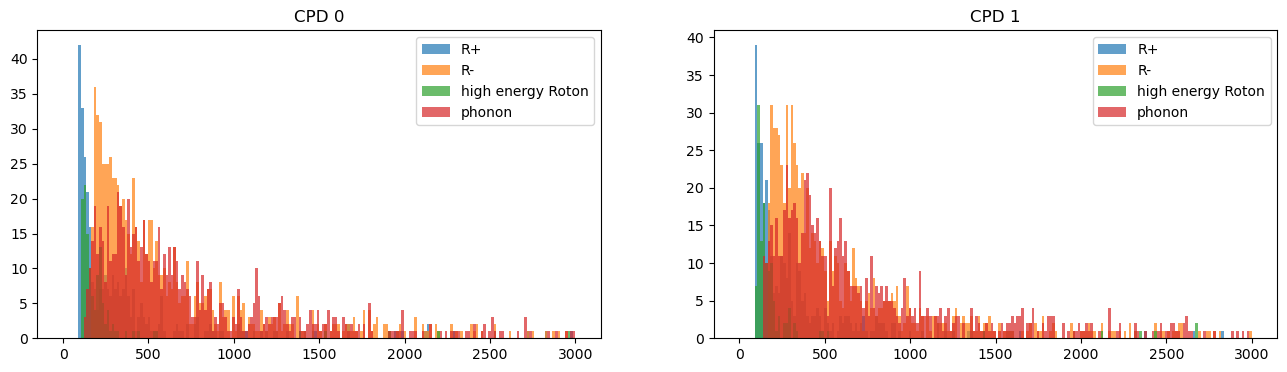

In [13]:
def plot_hist_flavors(evap):
    # we need 3 masks
    fs = evap.flavor
    fig, axs = plt.subplots(1,2, figsize =(16, 4))
    for i in range(2):
        for value in np.unique(fs[i]):
            mask = (fs[i] == value)
            print(mask)
            axs[i].hist(evap.arrivalTimes_us[i][mask], bins = 200, range = [0,3000], alpha= 0.7,stacked=True, label = value)
            axs[i].set_title(f'CPD {i}')
            axs[i].legend(loc = 'upper right')
            # plt.hist(evap.arrivalTimes_us[0][mask], stacked=True, label = value + 'CPD2')
plot_hist_flavors(evap)

In [ ]:
critical_angles = np.array([-0.99914392,  -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392])

random_numbs = np.array([-0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392, -0.99914392])
print((critical_angles > 1.19028995) & (random_numbs > 1.0))

In [3]:
def critical_angle(Energy, momentum, binding_energy = 0.00062e-3):
    m =  3.725472e6 #He mass in keV/c^2
    c = 2.998e8
    return np.arcsin(1 * np.sqrt(2 * m * (Energy - binding_energy))/np.abs(momentum))
def GetInterpFunc(d_path):
    """Creates an linear interpolation function from data found at the file path below,, giving us the ability to convert from resistance to temperature. 
    returns:
        Interpoltion function: If input exceeds range of the data function returns a NaN"""
    data = np.loadtxt(d_path, delimiter=',')
    X = data[:,0]
    Y = data[:,1]
    return interp1d(X,Y, kind = 'linear')

def QP_dispersion(p ):
    """generate the energy of the particle in meV

    Args:
        p (int): the momentum of the quasiparticle of interest 
        interp (funct): function to relate momentum and energy  
    """
    interp = GetInterpFunc('./dispersion_data.csv')
    energy = interp(p)
    return energy * 1e-3 #This is in eV 

def QP_velocity(p ):
    interp = GetInterpFunc('./velocity_data.csv')
    velocity = interp(p)
    return velocity

momentum = np.linspace(0.145, 4.7, 134)
# # need to print the dispersion curve here too
# plt.plot(momentum, QP_dispersion(momentum))
# # plt.plot(momentum, QP_velocity(momentum))
# plt.xlabel('Momenutm [KeV/c]')
# plt.ylabel('Velocity [m/s]')
# plt.title('Velocity Dispersion')
energy = QP_dispersion(momentum) *1e-3 
# plt.figure()
plt.plot(momentum, QP_dispersion(momentum)/np.max(QP_dispersion(momentum)), alpha = 0.3, label = 'normalized Dispersion Curve for reference')
plt.plot(momentum, critical_angle(energy, momentum, binding_energy=0.00062e-3), label = 'Critical Angle')
plt.axvline(3.84)
plt.legend()
plt.xlim(0, 4.7)
plt.xlabel('Momentum [KeV/c]')
plt.ylabel(r'$\theta_c$ in radians')
plt.title('Critical Evaporation Angle')


Text(0.5, 1.0, 'Critical Evaporation Angle')

In [29]:
from scipy.interpolate import interp1d
data = np.loadtxt('./dispersion_data.csv', delimiter=',')
X = data[:,0]
Y = data[:,1] * 1e-6 # this is now in keV
dispersion= interp1d(X, Y)
plt.figure()
plt.plot(X, Y)
plt.axhline(Y[63])
plt.axhline(Y[101])
plt.axhline(7.62432e-7)
plt.show()
print(X[63])
print(X[101])
print(dispersion(0.949))

2.3062001180524505
3.840354441491354
7.629762092133456e-07


In [17]:

momentum = np.linspace(0.145, 4.7, 134)
plt.plot(momentum, QP_dispersion(momentum)*1e3)
plt.title('Liquid Helium Dispersion Curve')
plt.xlabel('Momentum [KeV/c]')
plt.ylabel('Energy [meV]')

4.964218907074168


Text(0, 0.5, 'Energy [meV]')

In [7]:
from scipy.signal import argrelextrema
def get_phonon_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[0:63,1]
    Y = data[0:63,0]

    return interp1d(X,Y, kind = 'linear')
def get_rminus_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[63:101,1]
    Y = data[63:101,0]
    return interp1d(X,Y, kind = 'linear')
def get_rplus_mom_energy(d_path):
    data = np.loadtxt(d_path, delimiter=',')
    X = data[101:,1]
    Y = data[101:,0]
    print(X[0])

    return interp1d(X,Y, kind = 'linear')

phonon_interp = get_phonon_mom_energy('./dispersion_data.csv')
rminus_interp = get_rminus_mom_energy('./dispersion_data.csv')
rplus_interp = get_rplus_mom_energy('./dispersion_data.csv')
energy = np.linspace(764, 1225, 100) * 1e-3 # This is meV
plt.plot(energy, phonon_interp(energy))
plt.plot(energy, rminus_interp(energy))
plt.plot(energy, rplus_interp(energy))
plt.xlabel('energy')
plt.ylabel('Momentum')
plt.title('Inverting dispersion relation in the area of energy degeneracy')
plt.axhline(0.9555)
plt.axhline(4.565)

0.7624263496083991


In [14]:
print(rplus_interp(np.array(1.2259239975648981)))

4.561012643588033


In [27]:
@np.vectorize
def assign_flavors(p):
    if .955 < p <   2.168:
        flavor = 'phonon'
    elif 2.383 < p < 3.77:
        flavor = 'R-'
    elif 3.843<p < 4.541:

        flavor = 'R+'
    else:
        flavor = 'out_of_range'
    return flavor
@np.vectorize
def compute_conserved_mom(X, Y, dx, dy, dz, momentum):
    direction = np.array([dx, dy, dz])
    xy_vec = -1 * np.array([X, Y, 0], dtype = float) # compute the normal vector of the wall
    xy_vec = xy_vec/(np.sqrt(np.sum(xy_vec**2))) # normalize this vector
    dir_transverse = direction- np.dot(direction, xy_vec) * xy_vec
    conserved_momentum= momentum * dir_transverse
    conserved_magnitude = np.sum(conserved_momentum**2)
    return conserved_magnitude

def random_conversion(energy, momentum, flavor, X, Y, Z, dx, dy, dz):
    """ This function handles the conversion process, which is done by randomely choosing new momentums, that match the original. 

    Args:
        energy (_type_): _description_
        momentum (_type_): _description_
        flavor (_type_): _description_
        pos (_type_): _description_
        direction (_type_): _description_

    Returns:
        _type_: _description_
    """
    # generate a set of random numbers 
    r_nums = np.random.uniform(low = 0, high= 1, size = (len(energy), 3))
    old_momentum = momentum
    print(f'old momentum {old_momentum}')
    # decide on who goes where
    phonon_mom = phonon_interp(energy)
    rminus_mom = rminus_interp(energy)
    rplus_mom = rplus_interp(energy)
    flavors = np.column_stack((np.full(np.shape(phonon_mom), r'phonon'), np.full(np.shape(phonon_mom), r'R-') , np.full(np.shape(phonon_mom), r'R+')))
    
    conserved_mom= compute_conserved_mom(X, Y, dx, dy, dz, old_momentum)
    # compute the conserved momentum, which is the momentum in this direction

    phonon_mask = phonon_mom**2 < conserved_mom 
    rminus_mask = rminus_mom**2 < conserved_mom
    rplus_mask = rplus_mom**2 < conserved_mom
    # generate arrays of flavors
    r_nums[:,0][phonon_mask] = 0
    r_nums[:,1][rminus_mask] = 0
    r_nums[:,2][rplus_mask] = 0
    momentums = np.column_stack((phonon_mom, rminus_mom, rplus_mom))
    max_indices = np.argmax(r_nums, axis=1)  # Correct indexing along rows
    momentum = momentums[np.arange(len(energy)), max_indices]  # Select momenta for each energy
    flavor = flavors[np.arange(len(energy)), max_indices]
    print(f'starting direction {dx, dy, dz}')
    dx, dy, dz= convert_off_XY(old_momentum, momentum, X, Y, Z, dx, dy, dz)
    return momentum, flavor, dx, dy, dz


@np.vectorize
def convert_off_XY(old_momentum, new_momentum, X, Y, Z, dx, dy, dz):
    """Handles the converting and reflection off of XY surface (the cylindrical area) based upon QP kinematics. 
    Conserves the translational momentum, but does the longitudinal momentum.

    Args:
        old_momentum (float): This is the old momentum, aka the input momentum to the system. This will be negative if the input QP was previously a R- roton. 
        new_momentum (_type_): This is the new momentum, after conversion. This should be negative if the desired QP output is a R- roton. 
        pos (tuple or ndarray): This is the position of intersection with the wall
        direction (tuple or ndarray): This is the incident direction 
    """
    direction = np.array([dx, dy, dz])
    xy_vec = -1 * np.array([X, Y, 0], dtype = float) # compute the normal vector of the wall
    xy_vec = xy_vec/(np.sqrt(np.sum(xy_vec**2))) # normalize this vector
    dir_transverse = direction- np.dot(direction, xy_vec) * xy_vec
    # compute the conserved momentum, which is the momentum in this direction
    conserved_mom_parallel= old_momentum* dir_transverse
    print(f'Conserved momentum = {conserved_mom_parallel}')
    new_momentum_parallel= np.sqrt(new_momentum**2 - np.sum(conserved_mom_parallel**2))
    if new_momentum < 0:
        new_momentum_parallel = new_momentum_parallel *-1
    new_total_mom_vec = new_momentum_parallel * xy_vec + conserved_mom_parallel
    print(f'new momentum: {new_total_mom_vec}')
    new_total_mom_vec = new_total_mom_vec/new_momentum
    direction = new_total_mom_vec/np.linalg.norm(new_total_mom_vec, ord = 2)
    print(f'new direction {direction}')
    return direction[0], direction[1], direction[2]


    
def reflection(momentum, energy, pos, direction, flavor, surface):
    new_mom = random_conversion(energy, momentum)
    flavor = assign_flavors(new_mom)
        




    


   

In [ ]:
random_conversion(momentum=np.array([1.0,1.2,3.0]),energy=np.array([0.00080141, 0.00094112, 0.00107])*1e3, flavor=['phonon', 'phonon', 'phonon'], X = [3.0, -3.0, -3.0],Y= [0,0,0],Z = [1.5, 1.5, 1.5], dx = [1.0, 1.0, 1/np.sqrt(3)], dy = [0,0,-1/np.sqrt(3)],dz = [0,0,1/np.sqrt(3)])

In [8]:
def random_conversion_off_z(energy, momentum, old_flavor, dx, dy, dz):
    """Handles the random flavor switching off a surface of surface type 'Z'

    Args:
        energy (array): This should be in units of KeV 
        momentum (array): This should be in units of KeV/c, and it should have the same dimension as energy
        old_flavor (_type_): Describes the flavor of each QP, and it has the same dimension as the energy array. 
        dx (array): direction in x 
        dy (array): direction in y
        dz (array): Direction in Z

    Returns:
        _type_: _description_
    """

    r_nums = np.random.uniform(low = 0, high= 1, size = (len(energy), 3))
    old_momentum = momentum
    # decide on who goes where
    phonon_mom = phonon_interp(energy * 1e3)
    rminus_mom = rminus_interp(energy * 1e3)
    rplus_mom = rplus_interp(energy * 1e3)
    flavors = np.column_stack((np.full(np.shape(phonon_mom), r'phonon'), np.full(np.shape(phonon_mom), r'R-') , np.full(np.shape(phonon_mom), r'R+')))
    
    cons_x = momentum * dx
    cons_y = momentum * dy
    # compute the conserved momentum, which is the momentum in this direction
    conserved_mom_sq = (cons_x**2 + cons_y**2) 
    print(conserved_mom_sq)
    phonon_mask = phonon_mom**2 < conserved_mom_sq 
    rminus_mask = rminus_mom**2 < conserved_mom_sq
    rplus_mask = rplus_mom**2 < conserved_mom_sq
    print('masks')
    print(phonon_mask, rminus_mask, rplus_mask)
    # generate arrays of flavors
    r_nums[:,0][phonon_mask] = 0
    r_nums[:,1][rminus_mask] = 0
    r_nums[:,2][rplus_mask] = 0 
    momentums = np.column_stack((phonon_mom, -1 * rminus_mom, rplus_mom))
    print('momentums')
    print(momentums)
    max_indices = np.argmax(r_nums, axis=1)  # Correct indexing along rows
    print('random numbers')
    print(r_nums)
    momentum = momentums[np.arange(len(energy)), max_indices]  # Select momenta for each energy
    flavor = flavors[np.arange(len(energy)), max_indices]
    no_change_mask = (flavor == old_flavor)
    print('flavor and masks')
    print(flavor, no_change_mask)
    if len(dx[~no_change_mask]) >0: 
        dx[~no_change_mask], dy[~no_change_mask], dz[~no_change_mask] = conserve_z(momentum[~no_change_mask], conserved_mom_sq[~no_change_mask], 
                                                                                   dx[~no_change_mask], dy[~no_change_mask], dx[~no_change_mask])
    print('final momentum vector')
    print(momentum * dx, momentum * dy, momentum * dz)
    return dx, dy, dz

@np.vectorize
def conserve_z(momentum, conserved_mom, dx, dy, dz):
    dz_prime = np.sqrt(momentum**2 - conserved_mom)
    # pack them together
    new_direction_vec = np.array([dx, dy, dz_prime])
    # normalize
    new_direction_vec = new_direction_vec/np.linalg.norm(new_direction_vec)
    if momentum < 0:
        new_direction_vec[0] = -1 * new_direction_vec[0]  
        new_direction_vec[1] = -1 * new_direction_vec[1]  
    return new_direction_vec[0], new_direction_vec[1], new_direction_vec[2] 

In [17]:
dir_unnormalized = np.array([10.0,0 ,1.0])
dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
print(dir)
print(-3.6155 * dir) 
random_conversion_off_z(np.array([800]) * 1e-6, np.array([-3.6155]), 'R-', np.array([dir[0]]),np.array([dir[1]]),np.array([dir[2]]))


[0.99503719 0.         0.09950372]
[-3.59755696 -0.         -0.3597557 ]
[12.94241609]
masks
[ True] [False] [False]
momentums
[[ 0.99807671 -3.61554875  4.01182005]]
random numbers
[[0.         0.34913    0.52806375]]
flavor and masks
['R+'] [False]
final momentum vector
[1.9613524] [0.] [3.49968525]


(array([0.48889341]), array([0.]), array([0.87234353]))

False

In [26]:
print(phonon_interp(800.0 * 1e-3))

0.998076708935354


In [56]:
@np.vectorize
def assign_flavors(p, flavor):
    if .955 < p <   2.168:
        flavor = 'phonon'
    if 2.383 < p < 3.77:
        flavor = 'R-'
    if 3.843<p < 4.541:

        flavor = 'R+'
    return flavor




In [36]:
# I'm trying to figure out why this isn't working
X = [2.22, -1.34]
Y = [0, 2.67]
t = np.linspace(0, 5, 100)
path_x = []
path_y = []
for time in t:
    path_x.append(-0.34979062 * time - 1.34)
    path_y.append(-0.9368279* time +2.67)
plt.plot(path_x, path_y, label = 'new direction')
plt.plot(X, Y, label = 'final point')
plt.legend()

In [ ]:
flavor = np.full(10, 'out_of_degenerate_range')
momentum = np.random.uniform(low = .147, high = 4.7, size=10)
print(assign_flavors(momentum, flavor))

In [ ]:
plt.hist(evap.num_bounces, bins=20 )
plt.yscale('log')
plt.xlabel('number of bounces')
plt.ylabel('Counts per num of bounce')
plt.title('Understanding if we are gettign the expected number of bounces')
print(np.mean(evap.num_bounces))

In [ ]:
pos = [0., 0., 1.5]
useMap = False
evap = hest.GetEvaporationSignal( detector, 10, *pos, useMap=useMap, debug=False, plot_3d=True)


In [ ]:
plot_stacked_hist(evap)


In [ ]:
pos = [0., 0., 1.5]
useMap = False
evap = hest.GetEvaporationSignal( detector,1000, *pos, useMap=useMap, debug=False, plot_3d=False)
plot_stacked_hist(evap=evap)


# Status Update
At this point, everything above this is fully being used to 'flush' out, and as an active debugging site. Below this we will be beginning to run tests of the code, and this way I can save it for the future

In [3]:

detector = examp.Amherst_split_cpd 


QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )

QP_conditions.append( detector.liquid_surface )
detector.set_QP_reflection_prob(0.80)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff(1.0)

This code block is dedicated towards making a bunch of plots of the paths, where we are varying the momentum (with the same set of directions)

It is important to note that it saves this is a path _plots/adams-thesis_recreation_ with the name value of momentum + _xy.png_

In [ ]:
pos = [0.0, 0.0, 1.5]
moms = np.linspace(1.4, 4.7, 5)
directions_y = np.linspace(2, -2, 9)
paths = []
mom =4.4
for ii, dirs in enumerate(directions_y):
    print('\n')
    print(f'Starting the {ii}th direction')
    useMap = False
    dir_unnormalized = np.array([0, 1, 1])
    dir_unnormalized[1]= dirs
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    print(dir)
    evap = hest.GetEvaporationSignal( detector, 4, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom)
    paths.append(evap.positions)
plt.show()
plt.figure()
for ii, element in enumerate(paths):
    print(element[2][0,:])
    mask = (element[2][0,:] == 0)  & (element[1][0,:] == 0)
    plt.plot(element[1][0,:][~mask], element[2][0,:][~mask], label = (round(directions_y[ii], 2), 1))
plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
plt.axhline(2.75, color = 'b', lw = 3, label = 'liquid surface')
plt.legend(loc = 'lower left')
plt.xlabel('Y-coordinate')
plt.ylabel('Z-coordinate')
plt.title(f'This is with a momentum of {mom}')
plt.savefig(os.path.join('plots', 'adams-thesis_recreation',  str(mom) + 'xy.png'))
plt.show()

now we want to make a similar code block, except where we are varying the height of the liquid. 

In [ ]:

detector = examp.Amherst_split_cpd 
pos = [0.0, 0.0, 1.5]
QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
detector.set_QP_reflection_prob(0.80)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff(1.0)

directions_y = np.linspace(-1, 1, 10, dtype=float)
paths = []
h = 3.00
mom = 3.0
for ii, dirs in enumerate(directions_y):
    print('\n')
    print(f'Starting the {ii}th direction')
    useMap = False
    dir_unnormalized = np.array([0, 1, 1], dtype=float)
    dir_unnormalized[1]= dirs
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    evap = hest.GetEvaporationSignal( detector, 4, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, verbose = False)
    paths.append(evap.positions)
plt.show()
plt.figure()
bounces = evap.bounce_flag
for ii, element in enumerate(paths):
    print(element[2][0,:])
    mask = (element[2][0,0:3] == 0)  & (element[1][0,0:3] == 0)

    plt.plot(element[1][0,0:3][~mask], element[2][0,0:3][~mask], label = (round(directions_y[ii], 2), 1))
plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
plt.axhline(h,  color = 'b', lw = 3, label = 'liquid surface')
plt.legend(loc = 'lower left')
plt.xlabel('Y-coordinate')
plt.ylabel('Z-coordinate')
plt.title(f'This is with a momentum of {mom} and a height of {h}')
plt.savefig(os.path.join('plots', 'height_variance',  str(h)+'_' +str(mom) +  '_xy.png'))
plt.show()
plt.close('all')

In [ ]:

detector = examp.Amherst_split_cpd 
pos = [0.0, 0.0, 1.5]
QP_conditions= detector.get_surface_conditions()
nCPDs = detector.get_nCPDs()
for i in range(nCPDs):
    QP_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
detector.set_QP_reflection_prob(0.80)
detector.set_diffuse_prob(0.0)
detector.set_evaporation_eff(1.0)

directions_y = np.linspace(-1, 1, 10, dtype=float)
momentums = np.array([2.0, 2.5, 3.0, 3.5, 4.0, 4.5])
for mom in momentums:
    paths = []
    print(mom)
    h = 2.0
    for ii, dirs in enumerate(directions_y):
        print('\n')
        print(f'Starting the {ii}th direction')
        useMap = False
        dir_unnormalized = np.array([0, 1, 1], dtype=float)
        dir_unnormalized[1]= dirs
        dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
        evap = hest.GetEvaporationSignal( detector, 4, *pos, useMap=useMap, debug=True, debug_dir=dir,  plot_3d=True, choose_momentum=True, momentum_choice= mom, verbose = False)
        paths.append(evap.positions)
    plt.show()
    plt.figure()
    bounces = evap.bounce_flag
    for ii, element in enumerate(paths):
        print(element[2][0,:])
        mask = (element[2][0,0:3] == 0)  & (element[1][0,0:3] == 0)

        plt.plot(element[1][0,0:3][~mask], element[2][0,0:3][~mask])
    plt.axhline(3.3, color ='g', lw = 3, label = 'CPD surface')
    plt.axhline(h,  color = 'b', lw = 3, label = 'liquid surface')
    plt.legend(loc = 'lower left')
    plt.xlabel('Y-coordinate')
    plt.ylabel('Z-coordinate')
    plt.title(f'This is with a momentum of {mom} and a height of {h}')
    plt.savefig(os.path.join('plots', 'height_variance',  str(h)+'_' +str(mom) +  '_xy.png'))
    plt.show()
    plt.close('all')

In [14]:
plt.close('all')

In [ ]:
dir_unnormalized = np.array([0, 1, 1], dtype = float)
print(dir_unnormalized[1])
directions_y = np.linspace(-1, 1, 10)
for dy in directions_y:
    dir_unnormalized[1] = dy
    print(dy)
    print(dir_unnormalized)
    dir =dir_unnormalized/np.sqrt(np.sum(dir_unnormalized**2))
    print(dir)
 

# Questions

In [ ]:
n = np.array([[0,1,2],[4,5,6]])
print(n[:,0])

In [ ]:
probs = np.linspace(0, .9, 10)
counts = np.empty_like(probs)
for ii, p in enumerate(probs):   
    pos = [0., 0., 1.5]
    detector.set_QP_reflection_prob(p)
    
    useMap = False
    evap = hest.GetEvaporationSignal( detector, 50000,*pos, useMap=useMap)
    counts[ii] = len(evap.arrivalTimes_us[0])

plt.plot(probs, counts)
plt.title('Logical Check. As the number of reflections goes up, so the should the number of events we have')
plt.legend()



In [ ]:
import HeST.Detection as detection
import os
import numpy as np
#The detector geometry is defined from the point of view of particle paths.
# We essentially want to define various "surface conditions" where the particle paths are obstructed
# These functions also carry a "boundary_type", so that we can keep track if the particle is obstructed by
# a CPD, or a wall, and how it may reflect off of a given wall.

def sensor1_conditions(x, y, z):
    boundary_type = "CPD0"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) & (x>0)& (z < height)| (x*x + y*y >= radius*radius) , boundary_type

def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type





baseline_noise = [0., 0.]
phonon_conversion = 0.25
cpd1 = detection.VCPD(sensor1_conditions, baseline_noise, phonon_conversion)
cpd2 = detection.VCPD(sensor2_conditions, baseline_noise, phonon_conversion)





def wall_conditions(x, y, z):
    boundary_type = "XY"
    radius = 3. #cm
    height = 2.75 #cm
    return ((x*x + y*y < radius*radius) & (z < height) ) | (z > height), boundary_type

def bottom_conditions(x, y, z):
    boundary_type = "Z"
    bottom = 0. #cm
    return (z > bottom), boundary_type

def liquid_surface(x, y, z):
    boundary_type = "Liquid"
    height = 2.75 #cm
    return (z < height), boundary_type

def liquid_conditions(x, y, z):
    height = 2.75 #cm
    radius = 3. #cm
    bottom = 0. #cm
    return ((x*x + y*y < radius*radius) & (z < height) & (z > bottom))
   

Amherst_split_cpd = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

 

In [ ]:
def sensor2_conditions(x, y, z):
    boundary_type = "CPD1"
    radius = 3.8
    height = 3.3
    return (x*x + y*y < radius*radius) &  (x<0)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type

detector= detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)


cpd_2_x_bounds = np.linspace(0,-3.1, 10)
signals_cpd1 = np.empty_like(cpd_2_x_bounds)
signals_cpd2 = np.empty_like(cpd_2_x_bounds)


for ii, bound in enumerate(cpd_2_x_bounds):
    pos = [0., 0., 1.5]
    def sensor2_conditions(x, y, z):
        boundary_type = "CPD1"
        radius = 3.8
        height = 3.3
        print(bound)
        return (x*x + y*y < radius*radius) &  (x<bound)&(z < height)| (x*x + y*y >= radius*radius) , boundary_type
    cpd1 = detection.VCPD(sensor1_conditions, baseline_noise, phonon_conversion)
    cpd2 = detection.VCPD(sensor2_conditions, baseline_noise, phonon_conversion)


    detector = detection.VDetector([wall_conditions, bottom_conditions], liquid_surface=liquid_surface, liquid_conditions=liquid_conditions, CPDs=[cpd1, cpd2], adsorption_gain=6.0e-3, evaporation_eff=0.60)

    useMap = False
    evap = hest.GetEvaporationSignal( detector, 40000, *pos, useMap=useMap)
    print( evap.area_eV, evap.chArea_eV, evap.coincidence, len(evap.arrivalTimes_us))
    signals_cpd1[ii] = len(evap.arrivalTimes_us[0])
    signals_cpd2[ii] = len(evap.arrivalTimes_us[1])

plt.plot(cpd_2_x_bounds, signals_cpd1, label = 'Without changing size')
plt.plot(cpd_2_x_bounds, signals_cpd2, label = 'CPD2, with changing size')
plt.legend()
plt.xlabel('Where cpd1 starts')
plt.ylabel('Number of hits per')
plt.title('Testing if cpd 1 and 2 separation is working')


In [ ]:
def GetInterpFunc():
    """Creates an linear interpolation function from data found at the file path below,, giving us the ability to convert from resistance to temperature. 
    returns:
        Interpoltion function: If input exceeds range of the data function returns a NaN"""
    data = np.loadtxt('./dispersion_data.csv', delimiter=',')
    X = data[:,0]
    Y = data[:,1]
    return interp1d(X,Y, kind = 'linear')

In [ ]:
interp = GetInterpFunc()

In [ ]:
plt.subplot(211)
data = np.loadtxt('./dispersion_data.csv', delimiter=',')
v_data = np.loadtxt('./velocity_data.csv', delimiter=',')
X = data[:,0]
Y = data[:,1]
plt.plot(X, Y, label = 'Dispersion Curve')
plt.legend()
plt.show()
plt.subplot(212)
x = v_data[:,0]
y = v_data[:,1]
plt.plot(x[:-3], y[:-3], label = 'velocity')
plt.legend()
plt.show()

In [ ]:
def k_squared_distribution(u):
    N = (4.7**3 - .15**3)/3
    c = .15**3/(3 * N)
    return (3 * N* (u + c))**(1/3)

u = np.random.uniform(size=10000)
dist = k_squared_distribution(u)
plt.hist(dist, bins = 200)
plt.title('Distribution of K-values')
plt.xlabel('momenta')
plt.ylabel('counts/bin')

In [1]:
def find_surface_intersection(start, direction, up_conditions, down_conditions):
    """Finds the surface intersection by calculating the path, and finding the point right before the first intersection point.

    Args:
        start (_type_): _description_
        direction (_type_): _description_
        conditions (_type_): _description_

    Returns:
        _type_: _description_
    """
    print('~~~~~~~~~~~~~~~~ Finding Surface Intersection ~~~~~~~~~~~~~~~~~')
    def intersection(start, direction, conditions):
        if np.isscalar( start[0] ):
            start = np.array([np.array([p]) for p in start])
        if np.isscalar( direction[0] ):
            direction = np.array([np.array([p]) for p in direction])
        t = np.array([np.linspace(0, 10, 250) for i in range(len(start[0]))])  # Parameter range for the line
        # Calculate the line coordinates
        x_line = start[0][:, np.newaxis] + t * direction[0][:, np.newaxis]
        y_line = start[1][:, np.newaxis] + t * direction[1][:, np.newaxis]
        z_line = start[2][:, np.newaxis] + t * direction[2][:, np.newaxis]

        
        dist = np.ones(len(start[0]))*9999.
        coords = [np.full(len(start[0]), None), np.full(len(start[0]), None), np.full(len(start[0]), None)]
        surface_type = np.full(len(start[0]), None)
        for cond in conditions:
            cut, surface = cond(x_line, y_line, z_line)
            # the below line is meant to calculate the indices of the past point
            first_ints = np.array([np.argmax(~cut[i]) for i in range(len(cut))])
            #if first_int == 0:
            # continue
            # this determines how far the particle is ??
            d = t[np.arange(t.shape[0]), first_ints]
            cond = ( d < dist ) & (first_ints > 0)
            dist = np.where(cond, d, dist)        
        
            #get the coords of the first point *before* the interaction
            coords[0] = np.where(cond, x_line[np.arange(x_line.shape[0]), first_ints-1], coords[0])
            coords[1] = np.where(cond, y_line[np.arange(y_line.shape[0]), first_ints-1], coords[1])
            coords[2] = np.where(cond, z_line[np.arange(z_line.shape[0]), first_ints-1], coords[2])
            surface_type = np.where( cond, surface, surface_type )
        return np.array(coords[0], dtype = float), np.array(coords[1], dtype = float), np.array(coords[2], dtype= float), surface_type
    # we need to apply a mask to these things, and then everything should work WONDERFULLY
    up = direction[2] >0
    down = direction[2] <= 0
    surface_type = np.full(len(start[0]), None)
    X1 = np.full(len(start[0]), None)
    Y1 = np.full(len(start[0]), None)
    Z1 = np.full(len(start[0]), None)
    X1[up], Y1[up], Z1[up], surface_type[up] = intersection(start[:][up], direction[:][up], up_conditions)
    X1[down], Y1[down], Z1[down], surface_type[down] = intersection(start[:][down], direction[:][down], down_conditions)
    return X1, Y1, Z1, surface_type


In [ ]:

nCPDs = detector.get_nCPDs()
up_conditions = detector.get_up_conditions()

for i in range(nCPDs):
    up_conditions.append( (detector.get_CPD(i)).get_surface_condition() )
down_conditions = detector.get_down_conditions()
        